In [1]:
import duckdb
import requests
from pathlib import Path
import gzip
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

/Users/nicole/opt/anaconda3/lib/python3.9/site-packages/seaborn/utils.py:10: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 1.21.5)
  from scipy import stats


In [2]:
DATA_DIR = Path("./data") 

In [3]:
aggregate_data = False # @param ["False", "True"] {type:"raw"}

In [4]:
DATA_DIR = Path("../data")

DB_PATH = "ecommerce.duckdb"

# Connect to DuckDB (this creates a persistent file on disk)
con = duckdb.connect(DB_PATH)

IOException: IO Error: Could not set lock on file "/Users/nicole/Downloads/class+hw/data294/ecommerce/ECommerce-294P/notebooks/ecommerce.duckdb": Conflicting lock is held in /Users/nicole/opt/anaconda3/bin/python3.9 (PID 36238) by user nicole. See also https://duckdb.org/docs/stable/connect/concurrency

In [27]:
query_purchase_pair_freq = """
WITH purchases AS (
    SELECT
        user_session,
        product_id,
        SPLIT_PART(category_code, '.', 1) AS major_category
    FROM session_summary
    WHERE purchased = TRUE
      AND category_code IS NOT NULL
),

session_products AS (
    SELECT DISTINCT
        user_session,
        major_category,
        product_id
    FROM purchases
),

pairs AS (
    SELECT
        sp1.major_category AS base_category,
        sp1.product_id AS base_product,
        sp2.major_category AS co_category,
        sp2.product_id AS co_product,
        sp1.user_session
    FROM session_products sp1
    JOIN session_products sp2
      ON sp1.user_session = sp2.user_session
     AND (
          sp1.major_category <> sp2.major_category
          OR (sp1.major_category = sp2.major_category AND sp1.product_id <> sp2.product_id)
     )
)

SELECT
    base_category,
    co_category,
    COUNT(DISTINCT user_session) AS co_occurrence_count
FROM pairs
GROUP BY base_category, co_category
ORDER BY co_occurrence_count DESC;
"""

base_purchase_pairs = con.execute(query_purchase_pair_freq).fetchdf()
base_purchase_pairs.head(15)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,base_category,co_category,co_occurrence_count
0,construction,construction,144733
1,electronics,electronics,70030
2,appliances,appliances,39080
3,appliances,construction,25032
4,construction,appliances,25032
5,electronics,construction,20622
6,construction,electronics,20622
7,apparel,apparel,17218
8,apparel,construction,15537
9,construction,apparel,15537


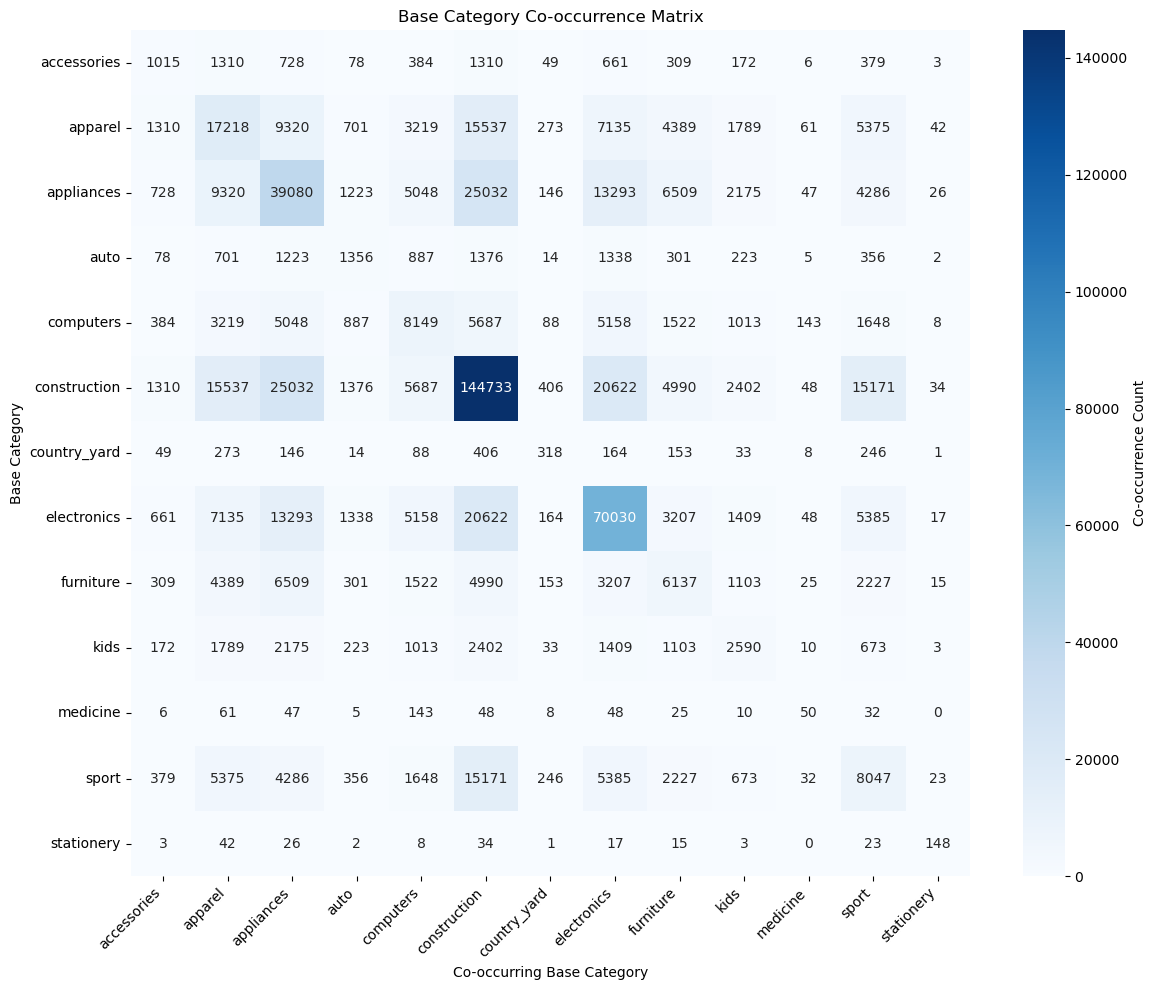

In [16]:
base_co_occurrence_matrix = base_purchase_pairs.pivot(
    index='base_category',
    columns='co_category',
    values='co_occurrence_count'
).fillna(0)  # fill NaNs with 0 for no co-occurrence

# Sort rows and columns alphabetically (optional)
base_co_occurrence_matrix = base_co_occurrence_matrix.sort_index(axis=0).sort_index(axis=1)

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    base_co_occurrence_matrix,
    annot=True,      # show counts inside the cells
    fmt='.0f',       # integer format
    cmap='Blues',    # color map
    cbar_kws={'label': 'Co-occurrence Count'}
)
plt.title('Base Category Co-occurrence Matrix')
plt.xlabel('Co-occurring Base Category')
plt.ylabel('Base Category')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Conclusion from base category analysis: 

There is greatest co-occurence within the categories of `construction`, `electronics`, and `appliances`. The greatest co-occurence first occurs within each category (`construction-construction`) then between itself and the other two categories. 

The other top co-occurences across and within categories are `apparel-apparel`, `construction-apparel`, and `sport-construction`. From this point on, co-occurence counts drop under 10000 (from ~13000 to 9000) in the data and will not be considered. 

Considering:
- `construction-construction` (144733 occurences)
    - A few light category products identified 
- `electronics-electronics` (70030 occurences)
    - Maybe just smartphones
- `appliances-appliances` (39080 occurences)

#### STILL NEED TO DO: 
- `construction-electronics` (20622 occurences)
- `construction-appliances` (25032 occurences)
- `electronics-appliances` (13293 occurences)
- `apparel-apparel` (17218 occurences)
- `construction-apparel` (15537 occurences)
- `sport-construction` (15171 occurences)

In [13]:
construction_pair_freq = """
WITH purchases AS (
    SELECT 
    SPLIT_PART(category_code, '.', 3) AS specific_category, 
        purchased, 
        user_session,
        product_id,
    FROM session_summary
    WHERE purchased = TRUE AND SPLIT_PART(category_code, '.', 1) = 'construction'
),

session_products AS (
    SELECT DISTINCT
        user_session,
        specific_category,
        product_id
    FROM purchases
),

pairs AS (
    SELECT
        sp1.specific_category AS base_category,
        sp1.product_id AS base_product,
        sp2.specific_category AS co_category,
        sp2.product_id AS co_product,
        sp1.user_session
    FROM session_products sp1
    JOIN session_products sp2
      ON sp1.user_session = sp2.user_session
     AND (
          sp1.specific_category <> sp2.specific_category
          OR (sp1.specific_category = sp2.specific_category AND sp1.product_id <> sp2.product_id)
     )
)

SELECT
    base_category,
    co_category,
    COUNT(DISTINCT user_session) AS co_occurrence_count
FROM pairs
GROUP BY base_category, co_category
ORDER BY co_occurrence_count DESC;
"""

construction_pairs = con.execute(construction_pair_freq).fetchdf()
construction_pairs.head()

,base_category,co_category,co_occurrence_count
0,light,light,136220
1,faucet,faucet,2538
2,light,faucet,1845
3,faucet,light,1845
4,light,welding,1095


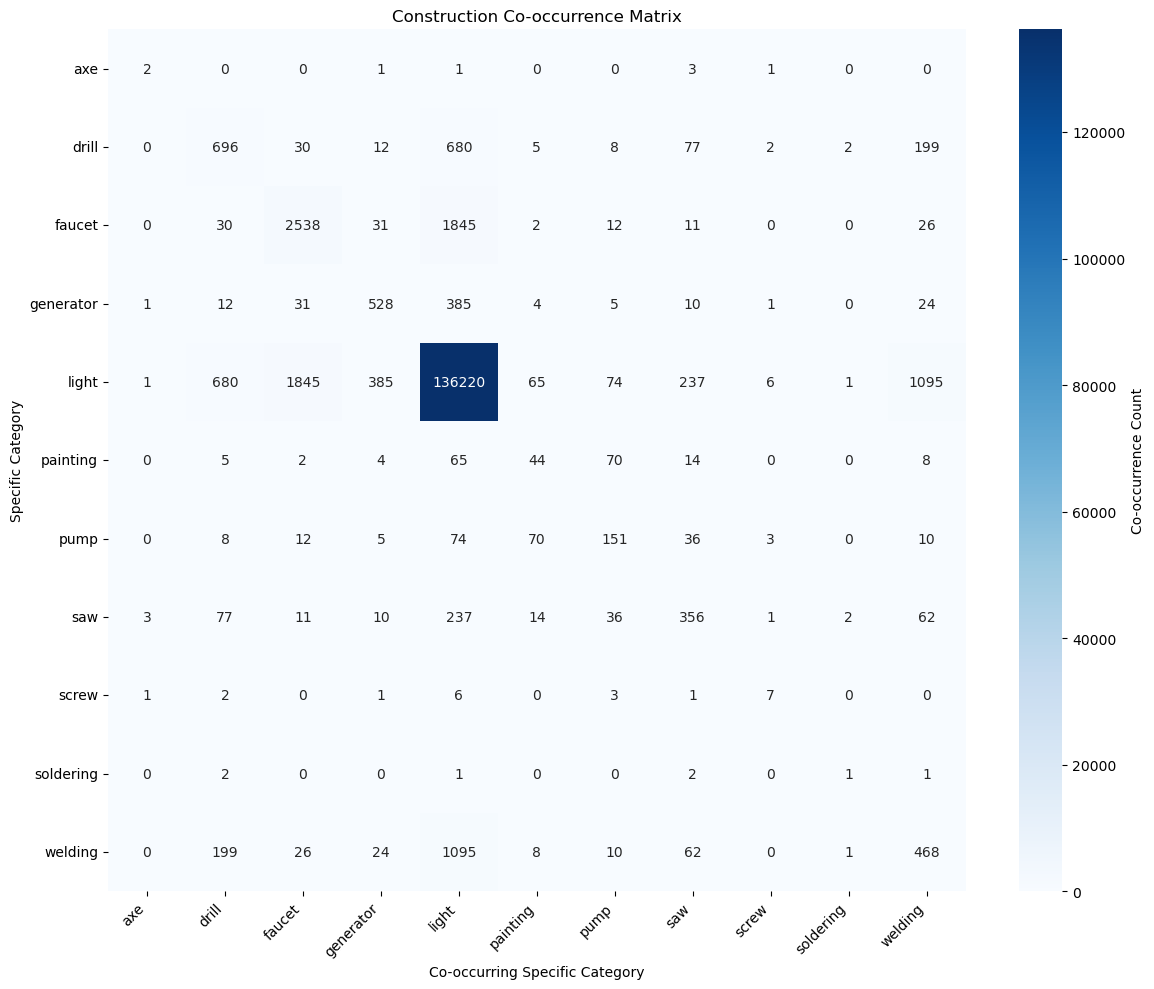

In [11]:
construction_co_occurrence_matrix = construction_pairs.pivot(
    index='base_category',
    columns='co_category',
    values='co_occurrence_count'
).fillna(0)  # fill NaNs with 0 for no co-occurrence

# Sort rows and columns alphabetically (optional)
construction_co_occurrence_matrix = construction_co_occurrence_matrix.sort_index(axis=0).sort_index(axis=1)

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    construction_co_occurrence_matrix,
    annot=True,      # show counts inside the cells
    fmt='.0f',       # integer format
    cmap='Blues',    # color map
    cbar_kws={'label': 'Co-occurrence Count'}
)
plt.title('Construction Co-occurrence Matrix')
plt.xlabel('Co-occurring Specific Category')
plt.ylabel('Specific Category')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [9]:
light_pair_freq = """
WITH purchases AS (
    SELECT 
        user_session,
        product_id,
    FROM session_summary
    WHERE purchased = TRUE AND SPLIT_PART(category_code, '.', 3) = 'light'
),

session_products AS (
    SELECT DISTINCT
        user_session,
        product_id
    FROM purchases
),

pairs AS (
    SELECT
        sp1.product_id AS base_product,
        sp2.product_id AS co_product,
        sp1.user_session
    FROM session_products sp1
    JOIN session_products sp2
      ON sp1.user_session = sp2.user_session
     AND sp1.product_id <> sp2.product_id
)

SELECT
    base_product,
    co_product,
    COUNT(DISTINCT user_session) AS co_occurrence_count
FROM pairs
GROUP BY base_product, co_product
ORDER BY co_occurrence_count DESC;
"""

light_pairs = con.execute(light_pair_freq).fetchdf()
light_pairs.head(20)[::2]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,base_product,co_product,co_occurrence_count
0,1005212,1005100,2771
2,1005100,1004767,2433
4,1005100,1004856,2206
6,1005115,1004249,1967
8,1004767,1005212,1912
10,1005105,1005115,1706
12,1002544,1005115,1690
14,1004767,1004856,1614
16,1002544,1004767,1338
18,1004856,1005212,1293


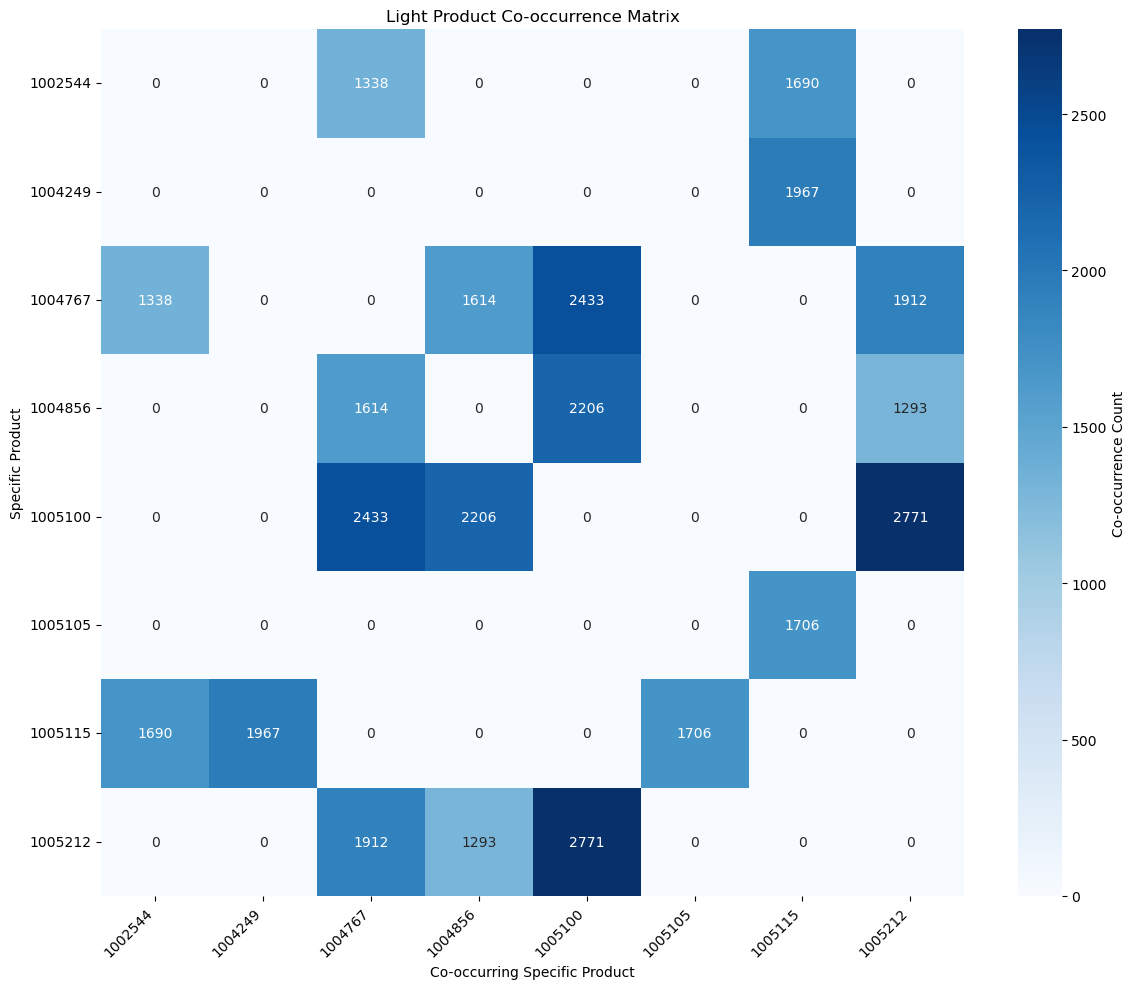

In [11]:
light_co_occurrence_matrix = light_pairs.head(20).pivot(
    index='base_product',
    columns='co_product',
    values='co_occurrence_count'
).fillna(0)  # fill NaNs with 0 for no co-occurrence

# Sort rows and columns alphabetically (optional)
light_co_occurrence_matrix = light_co_occurrence_matrix.sort_index(axis=0).sort_index(axis=1)

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    light_co_occurrence_matrix,
    annot=True,      # show counts inside the cells
    fmt='.0f',       # integer format
    cmap='Blues',    # color map
    cbar_kws={'label': 'Co-occurrence Count'}
)
plt.title('Light Product Co-occurrence Matrix')
plt.xlabel('Co-occurring Specific Product')
plt.ylabel('Specific Product')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Conclusion about `construction-construction` co-occurences

- Literally only lights. The cells above below indicates a 10 pairings of lightbulbs that we can maybe bundle or cross-sell
- Unique `product_ids` amongst the top 10 light pairings (> 1000 pairings, drops by 200 to the next pairing):
    - 1002544, 1004249, 1004856, 1005212, 1004767, 1005100, 1005105, 1005115
    - 544: 767, 115
    - 249: 115
    - 856: 212, 100, 767
    - 212: 767, 100, 856
    - 767: 212, 100, 544, 115
    - 100: 212, 856, 767
    - 105: 115
    - 115: 544, 249, 105
- Honestly, we can probably cross sell within any of the above 8 products pretty easily. The product ids continue to mix going down the sorted list
- I don't think bundling light bulbs would be a good idea. How often are you thinking "Wow buy two separate light bulb types for cheap!" I think people normally go looking for specific bulb types and this isn't a situation where you're interested in bonus items. 
    - Maybe bundle same light bulb packs? Like purchase three packs of the same bulb.

In [77]:
electronics_pair_freq = """
WITH purchases AS (
    SELECT 
        SUBSTRING(category_code, 13, 100) AS specific_category, 
        purchased, 
        user_session,
        product_id,
    FROM session_summary
    WHERE purchased = TRUE AND SPLIT_PART(category_code, '.', 1) = 'electronics'
),

session_products AS (
    SELECT DISTINCT
        user_session,
        specific_category,
        product_id
    FROM purchases
),

pairs AS (
    SELECT
        sp1.specific_category AS base_category,
        sp1.product_id AS base_product,
        sp2.specific_category AS co_category,
        sp2.product_id AS co_product,
        sp1.user_session
    FROM session_products sp1
    JOIN session_products sp2
      ON sp1.user_session = sp2.user_session
    AND (
          sp1.specific_category <> sp2.specific_category
          OR (sp1.specific_category = sp2.specific_category AND sp1.product_id <> sp2.product_id)
     )
)

SELECT
    base_category,
    co_category,
    COUNT(DISTINCT user_session) AS co_occurrence_count
FROM pairs
GROUP BY base_category, co_category
ORDER BY co_occurrence_count DESC;
"""

electronics_pairs = con.execute(electronics_pair_freq).fetchdf()
electronics_pairs.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,base_category,co_category,co_occurrence_count
0,smartphone,smartphone,41888
1,audio.headphone,audio.headphone,6342
2,clocks,clocks,5423
3,audio.headphone,smartphone,3181
4,smartphone,audio.headphone,3181
5,video.tv,video.tv,2234
6,smartphone,clocks,2162
7,clocks,smartphone,2162
8,smartphone,video.tv,2097
9,video.tv,smartphone,2097


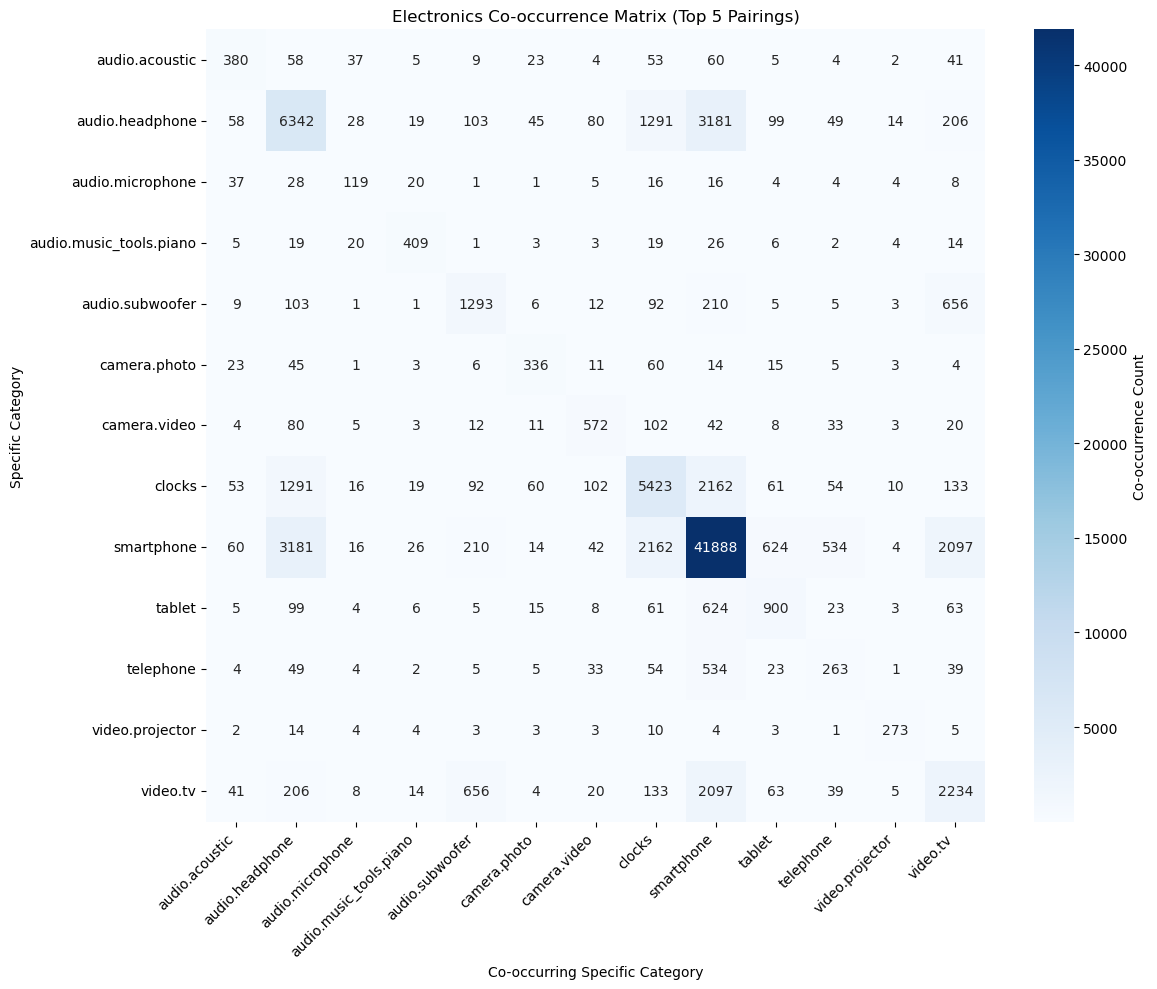

In [78]:
electronics_co_occurrence_matrix = electronics_pairs.pivot(
    index='base_category',
    columns='co_category',
    values='co_occurrence_count'
).fillna(0)  # fill NaNs with 0 for no co-occurrence

# Sort rows and columns alphabetically (optional)
electronics_co_occurrence_matrix = electronics_co_occurrence_matrix.sort_index(axis=0).sort_index(axis=1)

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    electronics_co_occurrence_matrix,
    annot=True,      # show counts inside the cells
    fmt='.0f',       # integer format
    cmap='Blues',    # color map
    cbar_kws={'label': 'Co-occurrence Count'}
)
plt.title('Electronics Co-occurrence Matrix')
plt.xlabel('Co-occurring Specific Category')
plt.ylabel('Specific Category')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

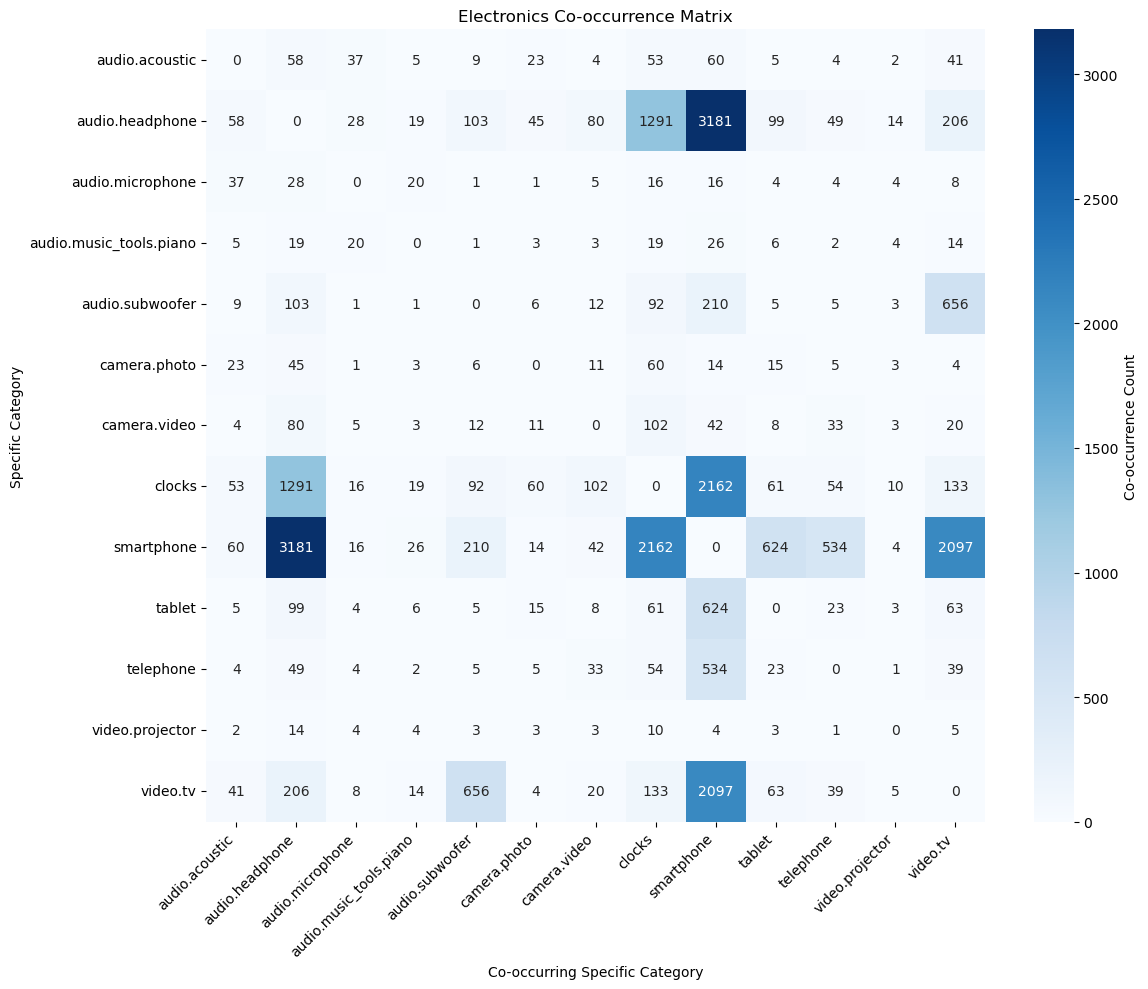

In [6]:
electronics_pair_freq = """
WITH purchases AS (
    SELECT 
        SUBSTRING(category_code, 13, 100) AS specific_category, 
        purchased, 
        user_session,
        product_id,
    FROM session_summary
    WHERE purchased = TRUE AND SPLIT_PART(category_code, '.', 1) = 'electronics'
),

session_products AS (
    SELECT DISTINCT
        user_session,
        specific_category,
        product_id
    FROM purchases
),

pairs AS (
    SELECT
        sp1.specific_category AS base_category,
        sp1.product_id AS base_product,
        sp2.specific_category AS co_category,
        sp2.product_id AS co_product,
        sp1.user_session
    FROM session_products sp1
    JOIN session_products sp2
      ON sp1.user_session = sp2.user_session
    AND (
          sp1.specific_category <> sp2.specific_category
     )
)

SELECT
    base_category,
    co_category,
    COUNT(DISTINCT user_session) AS co_occurrence_count
FROM pairs
GROUP BY base_category, co_category
ORDER BY co_occurrence_count DESC;
"""

electronics_pairs = con.execute(electronics_pair_freq).fetchdf()

electronics_co_occurrence_matrix = electronics_pairs.pivot(
    index='base_category',
    columns='co_category',
    values='co_occurrence_count'
).fillna(0)  # fill NaNs with 0 for no co-occurrence

# Sort rows and columns alphabetically (optional)
electronics_co_occurrence_matrix = electronics_co_occurrence_matrix.sort_index(axis=0).sort_index(axis=1)

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    electronics_co_occurrence_matrix,
    annot=True,      # show counts inside the cells
    fmt='.0f',       # integer format
    cmap='Blues',    # color map
    cbar_kws={'label': 'Co-occurrence Count'}
)
plt.title('Electronics Co-occurrence Matrix')
plt.xlabel('Co-occurring Specific Category')
plt.ylabel('Specific Category')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [77]:
electronics_pair_freq = """
WITH purchases AS (
    SELECT 
        SUBSTRING(category_code, 13, 100) AS specific_category, 
        purchased, 
        user_session,
        product_id,
    FROM session_summary
    WHERE purchased = TRUE AND SPLIT_PART(category_code, '.', 1) = 'electronics'
),

session_products AS (
    SELECT DISTINCT
        user_session,
        specific_category,
        product_id
    FROM purchases
),

pairs AS (
    SELECT
        sp1.specific_category AS base_category,
        sp1.product_id AS base_product,
        sp2.specific_category AS co_category,
        sp2.product_id AS co_product,
        sp1.user_session
    FROM session_products sp1
    JOIN session_products sp2
      ON sp1.user_session = sp2.user_session
    AND (
          sp1.specific_category <> sp2.specific_category
          OR (sp1.specific_category = sp2.specific_category AND sp1.product_id <> sp2.product_id)
     )
)

SELECT
    base_category,
    co_category,
    COUNT(DISTINCT user_session) AS co_occurrence_count
FROM pairs
GROUP BY base_category, co_category
ORDER BY co_occurrence_count DESC;
"""

electronics_pairs = con.execute(electronics_pair_freq).fetchdf()
electronics_pairs.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,base_category,co_category,co_occurrence_count
0,smartphone,smartphone,41888
1,audio.headphone,audio.headphone,6342
2,clocks,clocks,5423
3,audio.headphone,smartphone,3181
4,smartphone,audio.headphone,3181
5,video.tv,video.tv,2234
6,smartphone,clocks,2162
7,clocks,smartphone,2162
8,smartphone,video.tv,2097
9,video.tv,smartphone,2097


In [5]:
phones_pair_freq = """
WITH purchases AS (
    SELECT 
        purchased, 
        user_session,
        product_id,
    FROM session_summary
    WHERE purchased = TRUE AND SPLIT_PART(category_code, '.', 2) = 'smartphone'
),

session_products AS (
    SELECT DISTINCT
        user_session,
        product_id
    FROM purchases
),

pairs AS (
    SELECT
        sp1.product_id AS base_product,
        sp2.product_id AS co_product,
        sp1.user_session
    FROM session_products sp1
    JOIN session_products sp2
      ON sp1.user_session = sp2.user_session
    AND sp1.product_id <> sp2.product_id
)

SELECT
    base_product,
    co_product,
    COUNT(DISTINCT user_session) AS co_occurrence_count
FROM pairs
GROUP BY base_product, co_product
ORDER BY co_occurrence_count DESC;
"""

phones_pairs = con.execute(phones_pair_freq).fetchdf()
phones_pairs.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,base_product,co_product,co_occurrence_count
0,1004833,1004856,1107
1,1004856,1004833,1107
2,1004767,1004856,1105
3,1004856,1004767,1105
4,1004767,1004833,709
5,1004833,1004767,709
6,1005115,1004249,611
7,1004249,1005115,611
8,1005105,1005115,544
9,1005115,1005105,544


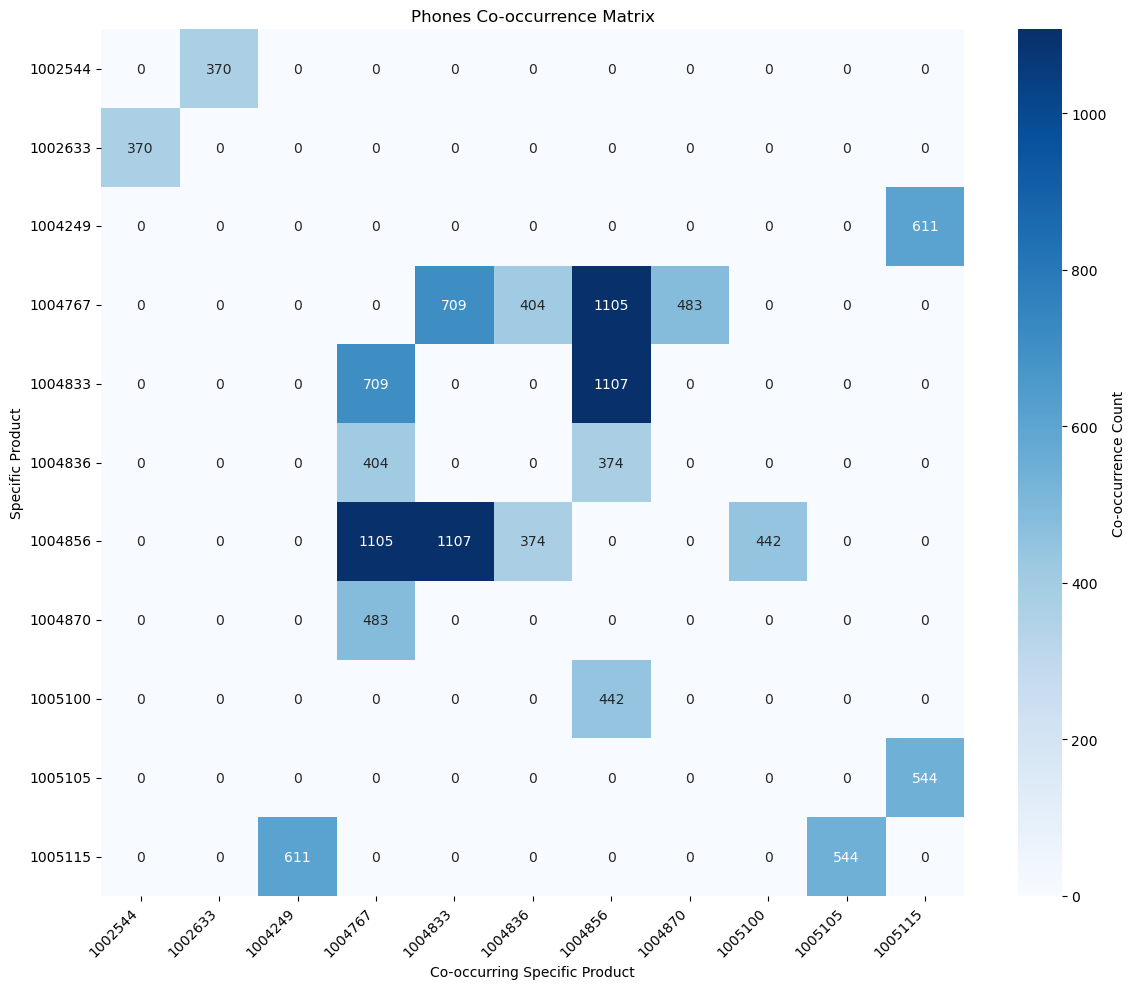

In [12]:
phones_co_occurrence_matrix = phones_pairs.head(20).pivot(
    index='base_product',
    columns='co_product',
    values='co_occurrence_count'
).fillna(0)  # fill NaNs with 0 for no co-occurrence

# Sort rows and columns alphabetically (optional)
phones_co_occurrence_matrix = phones_co_occurrence_matrix.sort_index(axis=0).sort_index(axis=1)

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    phones_co_occurrence_matrix,
    annot=True,      # show counts inside the cells
    fmt='.0f',       # integer format
    cmap='Blues',    # color map
    cbar_kws={'label': 'Co-occurrence Count'}
)
plt.title('Phones Co-occurrence Matrix')
plt.xlabel('Co-occurring Specific Product')
plt.ylabel('Specific Product')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Conclusion about `electronics-electronics` co-occurences

- Who out here buying that many smartphones
- Same categories: `smartphone-smartphone`, `clock-clock`, `tv-tv`, `headphone-headphone`, `subwoofer-subwoofer`
    - Strongest are `smartphone-smartphone`, `headphone-headphone`, `clocks-clocks`, and phones by far (order of magnitude). Clocks to the next category down falls by more than half (~5400 to 2200)
- Four cross-categories of interest: `clocks-headphones`, `smartphone-headphone`, `smartphone-clock`, `smartphone-tv`
- Ideally, someone will look into these

In [81]:
appliances_pair_freq = """
WITH purchases AS (
    SELECT 
        SUBSTRING(category_code, 12, 100) AS specific_category, 
        purchased, 
        user_session,
        product_id,
    FROM session_summary
    WHERE purchased = TRUE AND SPLIT_PART(category_code, '.', 1) = 'appliances'
),

session_products AS (
    SELECT DISTINCT
        user_session,
        specific_category,
        product_id
    FROM purchases
),

pairs AS (
    SELECT
        sp1.specific_category AS base_category,
        sp1.product_id AS base_product,
        sp2.specific_category AS co_category,
        sp2.product_id AS co_product,
        sp1.user_session
    FROM session_products sp1
    JOIN session_products sp2
      ON sp1.user_session = sp2.user_session
    AND (
          sp1.specific_category <> sp2.specific_category
          OR (sp1.specific_category = sp2.specific_category AND sp1.product_id <> sp2.product_id)
     )
)

SELECT
    base_category,
    co_category,
    COUNT(DISTINCT user_session) AS co_occurrence_count
FROM pairs
GROUP BY base_category, co_category
ORDER BY co_occurrence_count DESC;
"""

appliances_pairs = con.execute(appliances_pair_freq).fetchdf()
appliances_pairs.head(20)

,base_category,co_category,co_occurrence_count
0,personal.massager,personal.massager,6419
1,kitchen.refrigerators,kitchen.refrigerators,3679
2,kitchen.washer,kitchen.washer,3337
3,kitchen.washer,kitchen.refrigerators,2265
4,kitchen.refrigerators,kitchen.washer,2265
5,environment.vacuum,environment.vacuum,2112
6,kitchen.coffee_grinder,kitchen.coffee_grinder,2049
7,kitchen.refrigerators,personal.massager,1651
8,personal.massager,kitchen.refrigerators,1651
9,kitchen.washer,environment.vacuum,1169


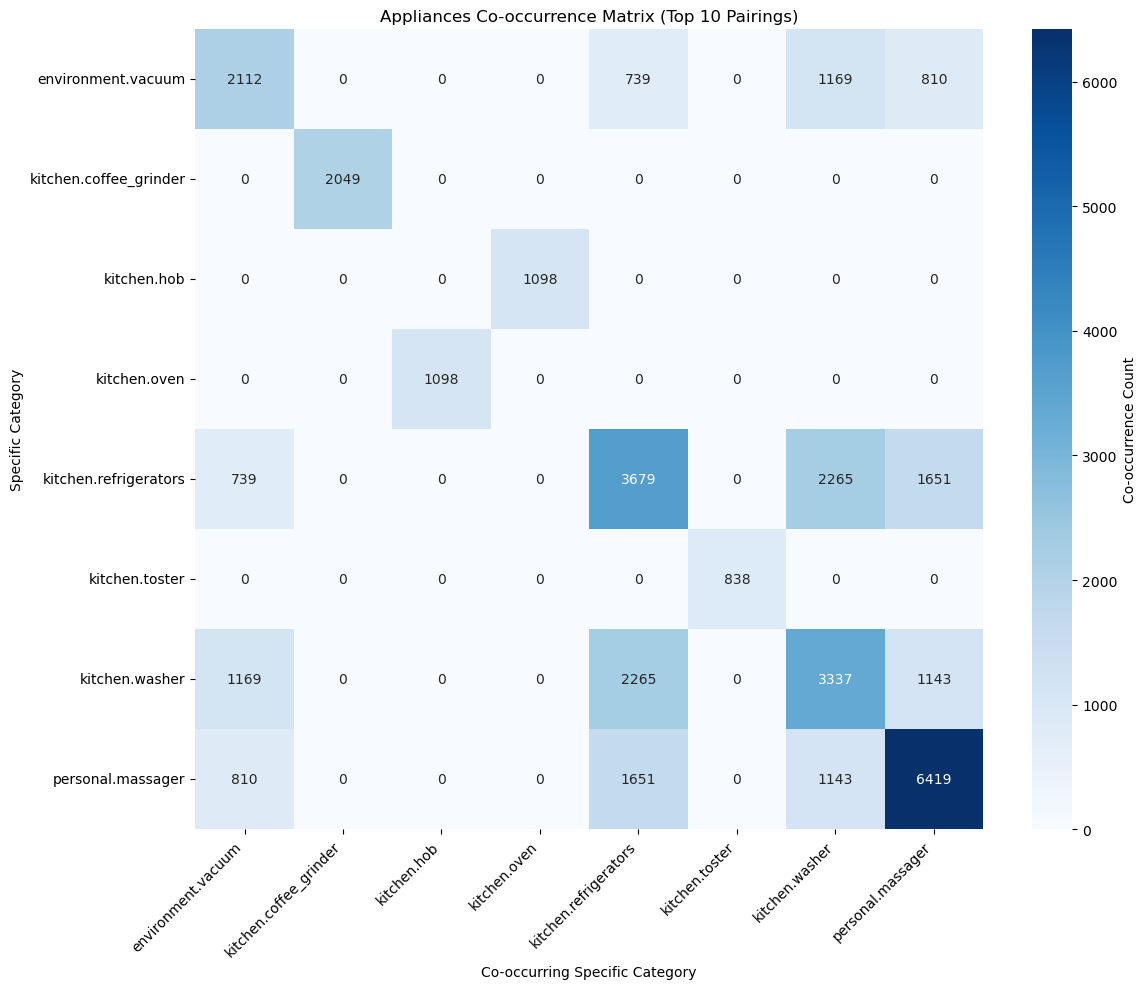

In [82]:
appliances_co_occurrence_matrix = appliances_pairs.head(20).pivot(
    index='base_category',
    columns='co_category',
    values='co_occurrence_count'
).fillna(0)  # fill NaNs with 0 for no co-occurrence

# Sort rows and columns alphabetically (optional)
appliances_co_occurrence_matrix = appliances_co_occurrence_matrix.sort_index(axis=0).sort_index(axis=1)

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    appliances_co_occurrence_matrix,
    annot=True,      # show counts inside the cells
    fmt='.0f',       # integer format
    cmap='Blues',    # color map
    cbar_kws={'label': 'Co-occurrence Count'}
)
plt.title('Appliances Co-occurrence Matrix')
plt.xlabel('Co-occurring Specific Category')
plt.ylabel('Specific Category')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Conclusion about `appliances-appliances` co-occurences

- I don't know what a massager is unless its like. a massage chair? who is buying multiple of these things. Actually most of the things on the diagonal unless its like a coffee grinder; who is purchasing multiple of these things at once
    - `massager-massager` category is items 1801881 and 1801690
- Other options might be `refrigerator-washer`. The next category drops by like 500 occurences. 

In [13]:
massager_pair_freq = """
WITH purchases AS (
    SELECT 
        purchased, 
        user_session,
        product_id,
    FROM session_summary
    WHERE purchased = TRUE AND 
        SPLIT_PART(category_code, '.', 3) = 'massager'
),

session_products AS (
    SELECT DISTINCT
        user_session,
        product_id
    FROM purchases
),

pairs AS (
    SELECT
        sp1.product_id AS base_product,
        sp2.product_id AS co_product,
        sp1.user_session
    FROM session_products sp1
    JOIN session_products sp2
      ON sp1.user_session = sp2.user_session
    AND sp1.product_id <> sp2.product_id
)

SELECT
    base_product,
    co_product,
    COUNT(DISTINCT user_session) AS co_occurrence_count
FROM pairs
GROUP BY base_product, co_product
ORDER BY co_occurrence_count DESC;
"""

massager_pairs = con.execute(massager_pair_freq).fetchdf()
massager_pairs.head(10)

,base_product,co_product,co_occurrence_count
0,1801881,1801690,160
1,1801690,1801881,160
2,1801940,1801766,94
3,1801766,1801940,94
4,1801766,1801806,91
5,1801806,1801766,91
6,1801690,1801739,83
7,1801739,1801690,83
8,1801995,1801940,75
9,1801940,1801995,75


In [5]:
wash_fridge_pair_freq = """
WITH purchases AS (
    SELECT 
        SPLIT_PART(category_code, '.', 3) AS specific_category, 
        purchased, 
        user_session,
        product_id,
    FROM session_summary
    WHERE purchased = TRUE AND 
        (SPLIT_PART(category_code, '.', 3) = 'washer' OR SPLIT_PART(category_code, '.', 3) = 'refrigerator')
),

session_products AS (
    SELECT DISTINCT
        specific_category, 
        user_session,
        product_id
    FROM purchases
),

pairs AS (
    SELECT
        sp1.specific_category AS base_category,
        sp1.product_id AS base_product,
        sp2.specific_category AS co_category,
        sp2.product_id AS co_product,
        sp1.user_session
    FROM session_products sp1
    JOIN session_products sp2
      ON sp1.user_session = sp2.user_session
    AND (sp1.product_id <> sp2.product_id)
)

SELECT
    base_product,
    co_product,
    COUNT(DISTINCT user_session) AS co_occurrence_count
FROM pairs
GROUP BY base_product, co_product
ORDER BY co_occurrence_count DESC;
"""

wash_fridge_pairs = con.execute(wash_fridge_pair_freq).fetchdf()
wash_fridge_pairs.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,base_product,co_product,co_occurrence_count
0,3600163,3601405,72
1,3601405,3600163,72
2,3600661,3601405,65
3,3601405,3600661,65
4,3600666,3600661,58
5,3600661,3600666,58
6,3601603,3600661,57
7,3600661,3601603,57
8,3601605,3601603,48
9,3601603,3601605,48


In [24]:
product_pair_freq = """
WITH purchases AS (
    SELECT 
        user_session,
        product_id,
        category_code, 
        price
    FROM session_summary
    WHERE purchased = TRUE 
),

pairs AS (
    SELECT
        mp1.user_session, 
        mp1.category_code AS base_category,
        mp1.product_id AS base_id,
        mp2.category_code AS co_category,
        mp2.product_id AS co_id,
        mp1.price AS base_price,
        mp2.price AS co_price,
        mp1.price + mp2.price AS total_price
    FROM purchases as mp1
    JOIN purchases as mp2
    ON mp1.user_session = mp2.user_session
        AND (mp1.product_id <> mp2.product_id
            OR (mp1.product_id = mp2.product_id AND mp1.category_code <> mp2.category_code)
        )
)

SELECT
    base_category,
    base_id,
    MEAN(base_price) AS base_price,
    co_category,
    co_id, 
    MEAN(co_price) AS co_price,
    MEAN(total_price) as avg_price,
    COUNT(DISTINCT user_session) AS co_occurrence_count
FROM pairs
GROUP BY base_category,
    base_id,
    co_category,
    co_id
ORDER BY co_occurrence_count DESC, base_category ASC
LIMIT 1000;
"""

product_pairs = con.execute(product_pair_freq).fetchdf()
product_pairs

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,base_category,base_id,base_price,co_category,co_id,co_price,avg_price,co_occurrence_count
0,construction.tools.light,1005100,143.501617,construction.tools.light,1005212,170.540604,314.042221,2771
1,construction.tools.light,1005212,170.540604,construction.tools.light,1005100,143.501617,314.042221,2771
2,construction.tools.light,1004767,235.045767,construction.tools.light,1005100,141.546817,376.592584,2433
3,construction.tools.light,1005100,141.546817,construction.tools.light,1004767,235.045767,376.592584,2433
4,construction.tools.light,1004856,129.823705,construction.tools.light,1005100,141.793912,271.617617,2206
...,...,...,...,...,...,...,...,...
995,electronics.clocks,5100855,538.392609,construction.tools.light,1005105,1255.194674,1793.587283,92
996,sport.bicycle,4803976,102.780652,sport.bicycle,4804056,159.995543,262.776196,92
997,sport.bicycle,4804056,159.995543,sport.bicycle,4803976,102.780652,262.776196,92
998,appliances.personal.massager,1801806,118.678022,appliances.personal.massager,1801766,156.450000,275.128022,91


In [78]:
ids = product_pairs[['base_category', 'base_id']]

In [84]:
single_freq = """
    SELECT 
        user_session,
        product_id,
        category_code, 
        MEAN(price) AS avg_price, 
        COUNT(product_id) AS item_count
    FROM session_summary
    WHERE purchased = TRUE
    GROUP BY user_session,
        product_id,
        category_code
        
"""

single_product = con.execute(single_freq).fetchdf()
single_product

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,user_session,product_id,category_code,avg_price,item_count
0,7fb9e7e9-a638-475a-9b9a-6ab3babb660f,1004870,electronics.smartphone,287.65,1
1,048460f7-9572-4599-ab8c-fde4dbd30977,1004939,electronics.smartphone,141.55,1
2,ed630faf-0de3-46de-87a8-3b73cde70ba4,1004144,electronics.smartphone,133.53,1
3,266c945a-9c62-4d27-841e-f9d4589799fd,1004870,electronics.smartphone,284.86,1
4,3e43afbe-c040-4b4b-8c89-56c427f5a761,4700422,auto.accessories.videoregister,105.12,1
...,...,...,...,...,...
6074127,96948304-670a-4064-9035-139fef9c867f,4804056,sport.bicycle,164.24,1
6074128,5848dbf6-3cb4-4fb6-8159-0d17a5b7b954,1005212,construction.tools.light,177.04,1
6074129,c1577ced-cd11-41d6-9390-7d96eceabd08,1005132,construction.tools.light,1333.32,1
6074130,799a73ab-555d-406d-ade0-442f1b27edcb,100153419,apparel.underwear,1.42,1


In [95]:
single_times = """
    WITH sing_freq AS (SELECT 
        user_session,
        product_id,
        category_code, 
        MEAN(price) AS avg_price, 
        COUNT(product_id) AS item_count
    FROM session_summary
    WHERE purchased = TRUE
    GROUP BY user_session,
        product_id,
        category_code), 
        
    purchases AS (
    SELECT 
        user_session,
        product_id,
        category_code, 
        price
    FROM session_summary
    WHERE purchased = TRUE 
),

pairs AS (
    SELECT
        mp1.user_session, 
        mp1.category_code AS base_category,
        mp1.product_id AS base_id,
        mp2.category_code AS co_category,
        mp2.product_id AS co_id,
        mp1.price AS base_price,
        mp2.price AS co_price,
        mp1.price + mp2.price AS total_price
    FROM purchases as mp1
    JOIN purchases as mp2
    ON mp1.user_session = mp2.user_session
        AND (mp1.product_id <> mp2.product_id
            OR (mp1.product_id = mp2.product_id AND mp1.category_code <> mp2.category_code)
        )
),

ids AS (SELECT
    base_category,
    base_id,
    MEAN(base_price) AS base_price,
    co_category,
    co_id, 
    MEAN(co_price) AS co_price,
    MEAN(total_price) as avg_price,
    COUNT(DISTINCT user_session) AS co_occurrence_count
FROM pairs
GROUP BY base_category,
    base_id,
    co_category,
    co_id
ORDER BY co_occurrence_count DESC, base_category ASC
LIMIT 1000)


SELECT 
    category_code, 
    product_id, 
    SUM(item_count) AS instances
    FROM sing_freq AS sf
    JOIN ids
    ON (ids.base_category = sf.category_code) AND (ids.base_id = sf.product_id)
    GROUP BY category_code, product_id
    ORDER BY instances DESC, category_code ASC
;   
        
"""

single_count = con.execute(single_times).fetchdf()
single_count

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,category_code,product_id,instances
0,construction.tools.light,1004767,5797476.0
1,construction.tools.light,1005100,5600800.0
2,construction.tools.light,1005115,4950651.0
3,construction.tools.light,1002544,2709917.0
4,construction.tools.light,1005212,2531430.0
...,...,...,...
150,sport.bicycle,4803976,2435.0
151,construction.tools.light,1003317,2310.0
152,construction.tools.light,1003316,2264.0
153,electronics.smartphone,100038678,1651.0


some construction light was purchased 5797476 times by itself, and with another light 2433 times. if we can get literally just 1% of the people (57974) who made those individual purchases to co-purchase the other light thats an additional 8206142. unlikely that that many people will copurchase this item given that only 2000 of them did so originally but ykwim.

In [99]:
product_pairs

,base_category,base_id,base_price,co_category,co_id,co_price,avg_price,co_occurrence_count
0,construction.tools.light,1005100,143.501617,construction.tools.light,1005212,170.540604,314.042221,2771
1,construction.tools.light,1005212,170.540604,construction.tools.light,1005100,143.501617,314.042221,2771
2,construction.tools.light,1004767,235.045767,construction.tools.light,1005100,141.546817,376.592584,2433
3,construction.tools.light,1005100,141.546817,construction.tools.light,1004767,235.045767,376.592584,2433
4,construction.tools.light,1004856,129.823705,construction.tools.light,1005100,141.793912,271.617617,2206
...,...,...,...,...,...,...,...,...
995,electronics.clocks,5100855,538.392609,construction.tools.light,1005105,1255.194674,1793.587283,92
996,sport.bicycle,4803976,102.780652,sport.bicycle,4804056,159.995543,262.776196,92
997,sport.bicycle,4804056,159.995543,sport.bicycle,4803976,102.780652,262.776196,92
998,appliances.personal.massager,1801806,118.678022,appliances.personal.massager,1801766,156.450000,275.128022,91


In [15]:
product_pair_freq = """
WITH purchases AS (
    SELECT 
        user_session,
        product_id,
        category_code, 
        price
    FROM session_summary
    WHERE purchased = TRUE 
),

pairs AS (
    SELECT
        mp1.user_session, 
        SPLIT_PART(mp1.category_code, '.', 1) AS b1,
        SPLIT_PART(mp1.category_code, '.', 2) AS s1, 
        SPLIT_PART(mp1.category_code, '.', 3) AS t1,
        mp1.product_id AS base_id,
        SPLIT_PART(mp2.category_code, '.', 1) AS b2,
        SPLIT_PART(mp2.category_code, '.', 2) AS s2, 
        SPLIT_PART(mp2.category_code, '.', 3) AS t2,
        mp2.product_id AS co_id,
        mp1.price AS base_price,
        mp2.price AS co_price,
        mp1.price + mp2.price AS total_price
    FROM purchases as mp1
    JOIN purchases as mp2
    ON mp1.user_session = mp2.user_session
        AND (
            (SPLIT_PART(mp1.category_code, '.', 2) <> SPLIT_PART(mp2.category_code, '.', 2))
            OR (
                (SPLIT_PART(mp1.category_code, '.', 2) = SPLIT_PART(mp2.category_code, '.', 2)) 
                AND (SPLIT_PART(mp1.category_code, '.', 3) <> SPLIT_PART(mp2.category_code, '.', 3))
                )
            )
)

SELECT
    CONCAT(b1, '.', s1, '.', t1) AS base_category,
    base_id,
    MEAN(base_price) AS base_price,
    CONCAT(b2, '.', s2, '.', t2) AS co_category,
    co_id, 
    MEAN(co_price) AS co_price,
    MEAN(total_price) as avg_price,
    COUNT(DISTINCT user_session) AS co_occurrence_count
FROM pairs
GROUP BY base_category,
    base_id,
    co_category,
    co_id
ORDER BY co_occurrence_count DESC, base_category ASC
LIMIT 1000;
"""

product_pairs = con.execute(product_pair_freq).fetchdf()
product_pairs

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,base_category,base_id,base_price,co_category,co_id,co_price,avg_price,co_occurrence_count
0,construction.tools.light,1005115,869.710725,sport.bicycle.,4804056,160.834681,1030.545406,690
1,sport.bicycle.,4804056,160.834681,construction.tools.light,1005115,869.710725,1030.545406,690
2,construction.tools.light,1002544,424.513581,sport.bicycle.,4804056,161.869343,586.382924,472
3,sport.bicycle.,4804056,161.869343,construction.tools.light,1002544,424.513581,586.382924,472
4,construction.tools.light,1004249,733.200398,sport.bicycle.,4804056,162.015321,895.215719,327
...,...,...,...,...,...,...,...,...
995,appliances.kitchen.refrigerators,2702277,470.515714,construction.tools.light,1004836,213.189524,683.705238,21
996,appliances.kitchen.refrigerators,2702331,507.189130,construction.tools.light,1005116,919.925652,1427.114783,21
997,appliances.kitchen.refrigerators,1005186,720.460000,construction.tools.light,1005116,961.019048,1681.479048,21
998,appliances.kitchen.washer,3601522,295.786667,construction.tools.light,1004767,233.752857,529.539524,21


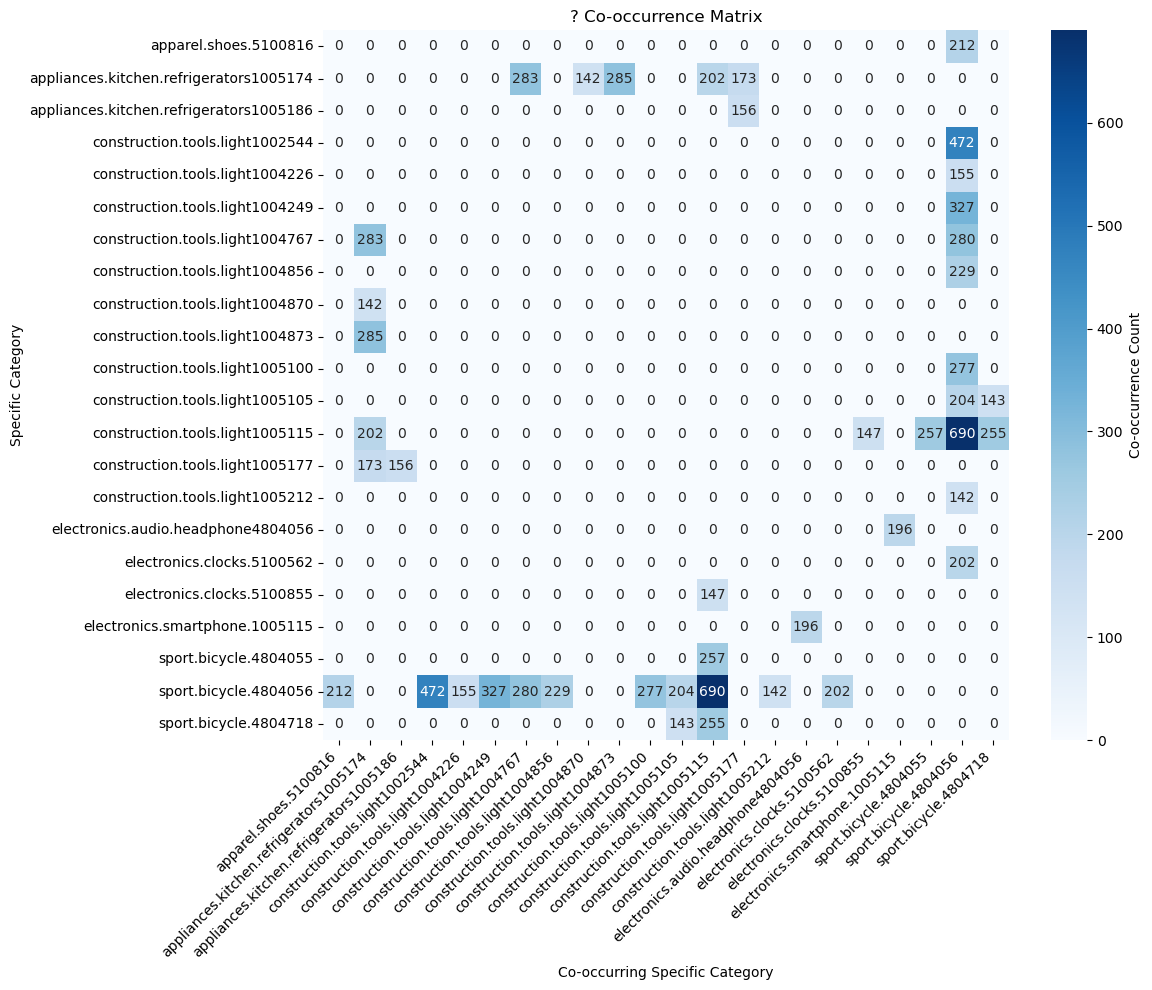

In [29]:
product_pairs['c1'] = product_pairs['base_category'].astype(str) + product_pairs['base_id'].astype(str)
product_pairs['c2'] = product_pairs['co_category'].astype(str) + product_pairs['co_id'].astype(str)


temp = product_pairs[:44].pivot(index='c1',
    columns='c2',
    values='co_occurrence_count'
).fillna(0)  # fill NaNs with 0 for no co-occurrence

# Sort rows and columns alphabetically (optional)
temp_matrix = temp.sort_index(axis=0).sort_index(axis=1)

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    temp_matrix,
    annot=True,      # show counts inside the cells
    fmt='.0f',       # integer format
    cmap='Blues',    # color map
    cbar_kws={'label': 'Co-occurrence Count'}
)
plt.title('? Co-occurrence Matrix')
plt.xlabel('Co-occurring Specific Category')
plt.ylabel('Specific Category')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [28]:
product_pairs

,base_category,base_id,base_price,co_category,co_id,co_price,avg_price,co_occurrence_count,c1,c2
0,construction.tools.light,1005115,869.710725,sport.bicycle.,4804056,160.834681,1030.545406,690,construction.tools.light1005115,sport.bicycle.4804056
1,sport.bicycle.,4804056,160.834681,construction.tools.light,1005115,869.710725,1030.545406,690,sport.bicycle.4804056,construction.tools.light1005115
2,construction.tools.light,1002544,424.513581,sport.bicycle.,4804056,161.869343,586.382924,472,construction.tools.light1002544,sport.bicycle.4804056
3,sport.bicycle.,4804056,161.869343,construction.tools.light,1002544,424.513581,586.382924,472,sport.bicycle.4804056,construction.tools.light1002544
4,construction.tools.light,1004249,733.200398,sport.bicycle.,4804056,162.015321,895.215719,327,construction.tools.light1004249,sport.bicycle.4804056
...,...,...,...,...,...,...,...,...,...,...
995,appliances.kitchen.refrigerators,2702277,470.515714,construction.tools.light,1004836,213.189524,683.705238,21,appliances.kitchen.refrigerators2702277,construction.tools.light1004836
996,appliances.kitchen.refrigerators,2702331,507.189130,construction.tools.light,1005116,919.925652,1427.114783,21,appliances.kitchen.refrigerators2702331,construction.tools.light1005116
997,appliances.kitchen.refrigerators,1005186,720.460000,construction.tools.light,1005116,961.019048,1681.479048,21,appliances.kitchen.refrigerators1005186,construction.tools.light1005116
998,appliances.kitchen.washer,3601522,295.786667,construction.tools.light,1004767,233.752857,529.539524,21,appliances.kitchen.washer3601522,construction.tools.light1004767
